# 02 – Bias Detection and Fairness Analysis
NovaCred Credit Application Dataset

## Goal

This notebook analyzes potential algorithmic bias in NovaCred’s historical credit application dataset.
While the previous notebook focused on data quality issues, this analysis examines whether historical lending decisions exhibit systematic disparities across demographic groups.

In particular, we evaluate whether the dataset reflects patterns of discrimination or structural bias, primarily related to demographic factors such as age or gender that could lead to unfair outcomes if used to train machine learning models.
Furthermore we will complement the traditional Data Quality dimensions by looking more closely into Fairness Metrics. 

## Objective
| Analysis Area       | Description                                                                                      |
| ------------------- | ------------------------------------------------------------------------------------------------ |
| Historical Bias     | Investigate whether past credit decisions reflect historical inequalities encoded in the dataset |
| Selection Bias      | Examine whether certain demographic groups are over- or under-represented in the dataset         |
| Measurement Bias    | Identify variables that may act as imperfect proxies for creditworthiness                        |
| Aggregation Bias    | Evaluate whether patterns differ across demographic groups, particularly age segments            |
| Fairness Metrics    | Measure potential gender disparities using the **Disparate Impact Ratio (80% rule)**             |
| Interaction Effects | Explore combined effects between variables such as age, gender, and financial characteristics    |

## Structure 
0. Initial Data Collection
1. Analysis of Bias Types
2. Fairness Metrics 
3. Interactions

## **0. Initial Data Collection**

In [183]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chisquare
from scipy.stats import pearsonr
import statsmodels.api as sm
from scipy.stats import chi2_contingency
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference



In [184]:
# Load cleaned dataset
df = pd.read_csv("../data/cleaned_credit_applications.csv")

# Quick check
df.head()

,_id,spending_behavior,processing_timestamp,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount
0,app_246,"[{'category': 'Healthcare', 'amount': 478}]",NaN,female,1991-10-11,90223.0,82000.0,31.0,0.29,21809.0,True,NaN,auto,2.8,38000.0
1,app_163,"[{'category': 'Shopping', 'amount': 404}]",2024-01-15T00:00:00Z,male,1981-06-03,10019.0,104000.0,58.0,0.30,38425.0,True,NaN,unknown,2.9,47000.0
2,app_214,"[{'category': 'Utilities', 'amount': 786}]",NaN,female,1962-08-26,90277.0,116000.0,84.0,0.31,41962.0,True,NaN,debt_consolidation,4.1,57000.0
3,app_177,"[{'category': 'Shopping', 'amount': 392}]",2024-01-15T00:00:00Z,male,1990-01-25,10004.0,54000.0,35.0,0.05,25705.0,True,NaN,unknown,5.9,67000.0
4,app_235,"[{'category': 'Travel', 'amount': 886}]",NaN,male,1997-08-31,10012.0,22000.0,16.0,0.28,12134.0,True,NaN,medical,5.4,39000.0


## **1. Analysis of Bias Types**

This section investigates potential sources of bias within the dataset and decision process. Specifically, we examine whether the data exhibits selection bias, age-related bias, and potential measurement bias through proxy variables. These analyses focus on understanding whether certain demographic groups are underrepresented in the dataset or indirectly affected by variables that capture sensitive information. Identifying these patterns helps determine whether the data itself may contribute to unfair outcomes in the lending decisions.

### **1.1. Selection Bias** 

Selection bias occurs when certain groups are over- or underrepresented in a dataset compared to the population the data is intended to represent. This can lead to models that perform differently across demographic groups because the training data does not reflect the true distribution of applicants. To assess potential selection bias, we examine whether the dataset is evenly distributed across key demographic attributes such as gender and age.

In [185]:
gender_counts = df["applicant_info.gender"].value_counts()
gender_percent = (gender_counts / len(df) * 100).round(2)

gender_summary = pd.DataFrame({
    "count": gender_counts,
    "percent": gender_percent
})

gender_summary

,count,percent
applicant_info.gender,,
female,251,50.2
male,247,49.4
unknown,2,0.4


In [186]:
# remove unknown gender
gender_df = df[df["applicant_info.gender"] != "unknown"]

# observed counts
observed = gender_df["applicant_info.gender"].value_counts().loc[["female","male"]]

# expected counts (50/50 assumption)
expected = [len(gender_df)/2, len(gender_df)/2]

chisquare(observed, expected)

Power_divergenceResult(statistic=np.float64(0.0321285140562249), pvalue=np.float64(0.8577458915859928))

In [187]:
# Convert date_of_birth to datetime
df["applicant_info.date_of_birth"] = pd.to_datetime(df["applicant_info.date_of_birth"])

# Calculate age using timestamp difference
df["age"] = ((pd.Timestamp.today() - df["applicant_info.date_of_birth"]).dt.days / 365.25).round(1)

# Check result
df["age"].describe()

count    496.000000
mean      41.236492
std       10.930050
min       23.900000
25%       32.475000
50%       39.650000
75%       47.525000
max       67.500000
Name: age, dtype: float64

In [188]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 25, 35, 45, 55, 65, 101],
    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"],
    right=False
)

age_counts = df["age_group"].value_counts().sort_index()
age_percent = (age_counts / len(df) * 100).round(2)

age_summary = pd.DataFrame({
    "count": age_counts,
    "percent": age_percent
})

age_summary

,count,percent
age_group,,
18-24,10,2.0
25-34,150,30.0
35-44,178,35.6
45-54,89,17.8
55-64,56,11.2
65+,13,2.6


In [189]:
from scipy.stats import chisquare

age_counts = df["age_group"].value_counts().sort_index()

expected = [age_counts.sum()/len(age_counts)] * len(age_counts)

chisquare(age_counts, expected)

Power_divergenceResult(statistic=np.float64(296.4596774193548), pvalue=np.float64(5.77768149034608e-62))

**Selection Bias - Summary**

The gender distribution in the dataset is nearly balanced (50.2% female, 49.4% male). A chi-square test comparing the observed distribution to a 50/50 expectation shows no significant difference (χ² = 0.03, p = 0.86), indicating no evidence of gender-based selection bias.

In contrast, the age distribution differs significantly from a uniform distribution (χ² = 296.46, p < 0.001). While a uniform distribution does not refelct real-world applications fully, the result still highlights a strong concentration of the 25–44 age groups, while very young (18–24) and older (65+) applicants are underrepresented. This indicates selection bias with respect to age representation in the dataset.

### **1.2. Age-Based Bias**

In [190]:
overall_approval_rate = df["decision.loan_approved"].mean()
print("Overall approval rate:", round(overall_approval_rate, 3))

approved_df = df[df["decision.loan_approved"] == True]

Overall approval rate: 0.584


In [191]:
approval_by_age = (
    df.groupby("age_group")["decision.loan_approved"]
    .mean().round(2)
)

approval_summary = approval_by_age.reset_index()
approval_summary["overall_avg"] = overall_approval_rate.round(2)

approval_summary["diff_from_avg"] = (
    approval_summary["decision.loan_approved"] - overall_approval_rate
).round(2)

approval_summary

C:\Users\Behnia\AppData\Local\Temp\ipykernel_6424\1405855041.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["decision.loan_approved"]


,age_group,decision.loan_approved,overall_avg,diff_from_avg
0,18-24,0.50,0.58,-0.08
1,25-34,0.45,0.58,-0.13
2,35-44,0.66,0.58,0.08
3,45-54,0.64,0.58,0.06
4,55-64,0.62,0.58,0.04
5,65+,0.54,0.58,-0.04


In [192]:
overall_interest = approved_df["decision.interest_rate"].mean()
print("Overall average interest rate:", round(overall_interest, 3))

Overall average interest rate: 4.565


In [193]:
interest_by_age = (
    approved_df.groupby("age_group")["decision.interest_rate"]
    .mean().round(2)
)

interest_summary = interest_by_age.reset_index()
interest_summary["overall_avg"] = overall_interest.round(2)

# deviation from overall average
interest_summary["diff_from_avg"] = (
    interest_summary["decision.interest_rate"] - interest_summary["overall_avg"]
).round(2)

interest_summary

C:\Users\Behnia\AppData\Local\Temp\ipykernel_6424\2153335548.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approved_df.groupby("age_group")["decision.interest_rate"]


,age_group,decision.interest_rate,overall_avg,diff_from_avg
0,18-24,4.54,4.56,-0.02
1,25-34,4.42,4.56,-0.14
2,35-44,4.55,4.56,-0.01
3,45-54,4.68,4.56,0.12
4,55-64,4.51,4.56,-0.05
5,65+,5.37,4.56,0.81


C:\Users\Behnia\AppData\Local\Temp\ipykernel_6424\3163098807.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["decision.loan_approved"]
C:\Users\Behnia\AppData\Local\Temp\ipykernel_6424\3163098807.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approved_df.groupby("age_group")["decision.interest_rate"]


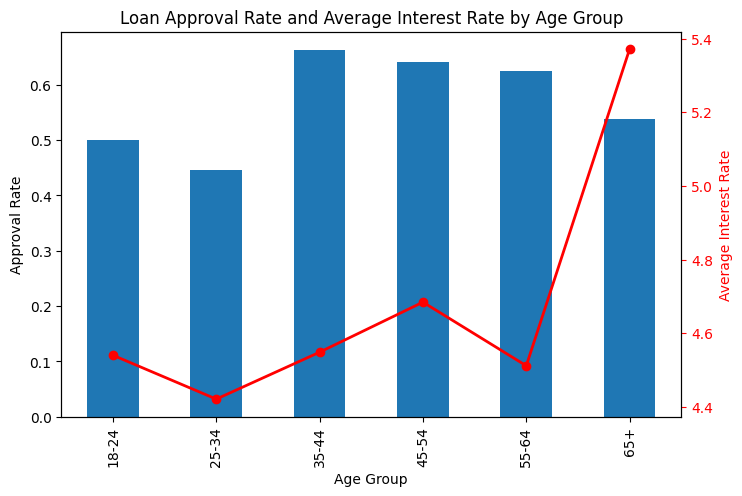

In [194]:
# approval rate per age group
approval_rate = (
    df.groupby("age_group")["decision.loan_approved"]
    .mean()
)

# average interest rate for approved loans
avg_interest = (
    approved_df.groupby("age_group")["decision.interest_rate"]
    .mean()
)

fig, ax1 = plt.subplots(figsize=(8,5))

# bar chart → approval rate
approval_rate.plot(
    kind="bar",
    ax=ax1
)

ax1.set_xlabel("Age Group")
ax1.set_ylabel("Approval Rate")
ax1.set_title("Loan Approval Rate and Average Interest Rate by Age Group")

# second axis → interest rate
ax2 = ax1.twinx()

ax2.plot(
    avg_interest.index,
    avg_interest.values,
    marker="o",
    linewidth=2,
    color="red"
)

ax2.set_ylabel("Average Interest Rate", color="red")
ax2.tick_params(axis='y', colors='red')

plt.show()

In [195]:
overall_amount = approved_df["decision.approved_amount"].mean()
print("Overall average approved amount:", round(overall_amount, 2))

Overall average approved amount: 47845.89


In [196]:
amount_by_age = (
    approved_df.groupby("age_group")["decision.approved_amount"]
    .mean().round(2)
)

amount_summary = amount_by_age.reset_index()
amount_summary["overall_avg"] = overall_amount.round(2)

# deviation from overall average
amount_summary["diff_from_avg"] = (
    amount_summary["decision.approved_amount"] - amount_summary["overall_avg"]
).round(2)

amount_summary

C:\Users\Behnia\AppData\Local\Temp\ipykernel_6424\1120276433.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approved_df.groupby("age_group")["decision.approved_amount"]


,age_group,decision.approved_amount,overall_avg,diff_from_avg
0,18-24,34600.00,47845.89,-13245.89
1,25-34,47985.07,47845.89,139.18
2,35-44,47550.85,47845.89,-295.04
3,45-54,47526.32,47845.89,-319.57
4,55-64,48914.29,47845.89,1068.40
5,65+,58428.57,47845.89,10582.68


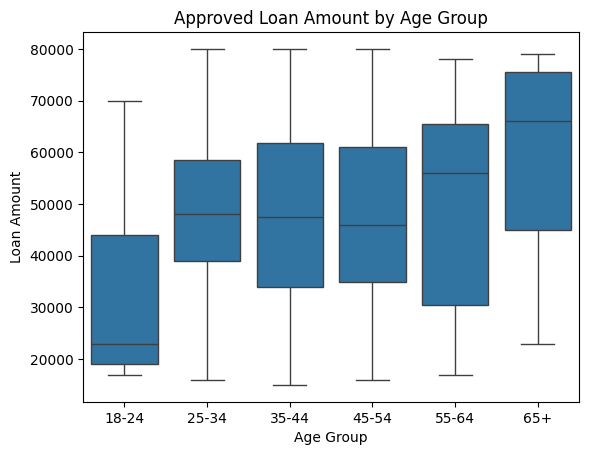

In [197]:
sns.boxplot(
    data=approved_df,
    x="age_group",
    y="decision.approved_amount"
)

plt.title("Approved Loan Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Loan Amount")
plt.show()

**Age-based Bias - Summary**

To evaluate potential age-related bias, we compared loan outcomes across age groups, focusing on approval rates, interest rates, and approved loan amounts. Since a selection bias was already identified, findings regarding the both age extremes should be taken into account with caution. 

Approval rates show moderate variation across age groups. Middle-aged applicants (35–54) exhibit the highest approval probabilities, while younger applicants (18–24) have slightly lower approval rates. 

Interest rates remain relatively stable across most age groups, with only minor deviations from the overall average. However, applicants aged 65+ receive noticeably higher interest rates compared to the dataset average.

A similar pattern appears for approved loan amounts. Younger applicants (18–24) receive substantially smaller loans on average, while older applicants—particularly the 65+ group—receive larger approved loan amounts.

Overall, the results suggest moderate differences in lending outcomes across age groups, primarily affecting younger applicants through lower loan amounts and slightly reduced approval rates. However, these differences likely reflect underlying financial characteristics such as credit history rather than explicit age-based discrimination, which will be assessed in further analyses. 

### **1.3. Measurement Bias Analysis** (Proxy Discrimination)

Proxy discrimination occurs when non-protected variables indirectly encode protected characteristics. Protected variables are characteristics that should not be used to make decisions, because doing so would lead to discrimination. 

Even if attributes such as gender or age are not explicitly used in decision-making, correlated variables can reproduce discriminatory patterns. Therefore, we analyze whether certain financial or geographic attributes in the dataset act as proxies for protected characteristics.

In [198]:
model_df = df[[
    "decision.loan_approved",
    "financials.credit_history_months",
    "financials.annual_income",
    "financials.debt_to_income",
    "financials.savings_balance"
]].dropna()

X = model_df[[
    "financials.credit_history_months",
    "financials.annual_income",
    "financials.debt_to_income",
    "financials.savings_balance"
]]

X = sm.add_constant(X)
y = model_df["decision.loan_approved"]

model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.658966
         Iterations 5
                             Logit Regression Results                             
Dep. Variable:     decision.loan_approved   No. Observations:                  497
Model:                              Logit   Df Residuals:                      492
Method:                               MLE   Df Model:                            4
Date:                    Fri, 06 Mar 2026   Pseudo R-squ.:                 0.02970
Time:                            21:05:53   Log-Likelihood:                -327.51
converged:                           True   LL-Null:                       -337.53
Covariance Type:                nonrobust   LLR p-value:                 0.0004882
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                           

Logistic regression analysis shows that credit history length and annual income significantly influence loan approval decisions. In particular, longer credit histories increase the probability of approval (p = 0.026). Since credit history length is strongly correlated with applicant age (r = 0.652), it may act as an indirect proxy for age in lending decisions. 

Note: The pseudo R-squared is very low due to simplicity of the model. 

 In our further analysis credit history months and annual income as possible proxies. Additionally, we will innvestigate ZIP Codes since they tend to be a typical Proxy.  


In [199]:
# Protected attributes
protected_vars = [
    "applicant_info.gender",
    "age"
]

# Potential proxy variables
proxy_vars = [
    "applicant_info.zip_code",
    "financials.credit_history_months",
    "financials.annual_income",
]

print("Protected attributes:", protected_vars)
print("Potential proxy variables:", proxy_vars)

Protected attributes: ['applicant_info.gender', 'age']
Potential proxy variables: ['applicant_info.zip_code', 'financials.credit_history_months', 'financials.annual_income']


#### **1.3.1 Age as protected variable**

 This analysis investigates if previous identified age-biased patterns might be related to one of the potential financial proxies identified through our regression. 

In [200]:
proxy_age_corr = df[
    ["age"] + proxy_vars[1:]  # exclude zip_code since it's categorical
].corr()

age_proxy_candidates = proxy_age_corr["age"].drop("age").sort_values(ascending=False)

age_proxy_candidates

financials.credit_history_months    0.651986
financials.annual_income            0.394071
Name: age, dtype: float64

We first test whether numeric financial variables are strongly associated with applicant age. A strong relationship would suggest that these variables may indirectly encode age and therefore function as age proxies in downstream decision-making. In this case, `credit_history_months` could be a potential proxy threat. 

In [201]:
approval_by_credit_history = (
    df.groupby("financials.credit_history_months")["decision.loan_approved"]
    .mean()
)

In [202]:
df["credit_history_group"] = pd.cut(
    df["financials.credit_history_months"],
    bins=[0,12,36,60,1000],
    labels=["0-1y","1-3y","3-5y","5y+"]
)

In [203]:
approval_by_history = (
    df.groupby("credit_history_group")["decision.loan_approved"]
    .mean()
)

approval_by_history

C:\Users\Behnia\AppData\Local\Temp\ipykernel_6424\575246150.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("credit_history_group")["decision.loan_approved"]


credit_history_group
0-1y    0.411765
1-3y    0.530435
3-5y    0.639456
5y+     0.630682
Name: decision.loan_approved, dtype: float64

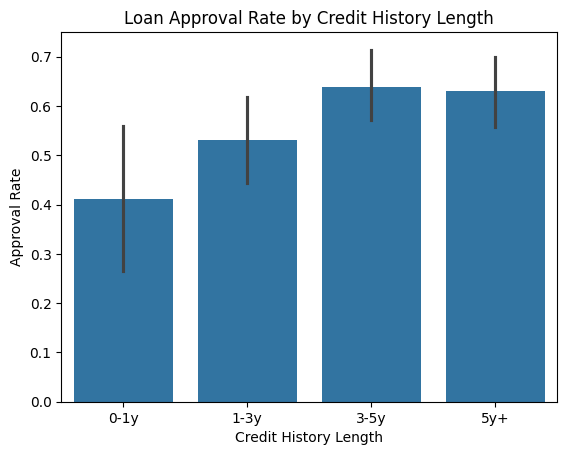

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=df,
    x="credit_history_group",
    y="decision.loan_approved"
)

plt.title("Loan Approval Rate by Credit History Length")
plt.xlabel("Credit History Length")
plt.ylabel("Approval Rate")

plt.show()

In [205]:
sample_sizes = (
    df.groupby(["credit_history_group", "age_group"])
    .size()
    .reset_index(name="n")
)
sample_sizes

C:\Users\Behnia\AppData\Local\Temp\ipykernel_6424\1376313632.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["credit_history_group", "age_group"])


,credit_history_group,age_group,n
0,0-1y,18-24,3
1,0-1y,25-34,19
2,0-1y,35-44,10
3,0-1y,45-54,1
4,0-1y,55-64,0
5,0-1y,65+,0
6,1-3y,18-24,5
7,1-3y,25-34,51
8,1-3y,35-44,50
9,1-3y,45-54,7


In [206]:
approval_age_history = (
    df.groupby(["credit_history_group", "age_group"])["decision.loan_approved"]
    .mean()
    .reset_index()
)

approval_age_history = approval_age_history.merge(
    sample_sizes,
    on=["credit_history_group", "age_group"]
)

filtered_data = approval_age_history[approval_age_history["n"] >= 5]

C:\Users\Behnia\AppData\Local\Temp\ipykernel_6424\2851209345.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["credit_history_group", "age_group"])["decision.loan_approved"]


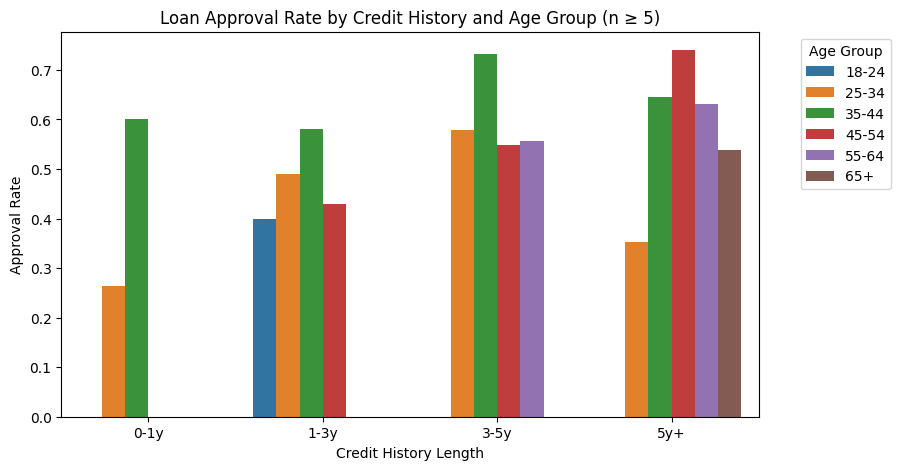

In [207]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=filtered_data,
    x="credit_history_group",
    y="decision.loan_approved",
    hue="age_group"
)

plt.title("Loan Approval Rate by Credit History and Age Group (n ≥ 5)")
plt.xlabel("Credit History Length")
plt.ylabel("Approval Rate")

plt.legend(title="Age Group", bbox_to_anchor=(1.05,1))
plt.show()

In [208]:
corr_df = df[["age", "financials.credit_history_months"]].dropna()

corr, p_value = pearsonr(
    corr_df["age"],
    corr_df["financials.credit_history_months"]
)

print("Correlation:", round(corr,3))
print("p-value:", p_value)

Correlation: 0.652
p-value: 4.004717380005526e-61


The analysis reveals a strong positive correlation between applicant age and credit history length (r = 0.652, p < 0.001), indicating that older applicants tend to have substantially longer credit histories. This relationship is expected from a financial perspective, as individuals naturally accumulate credit history over time.

The logistic regression results further show that credit history length significantly increases the probability of loan approval (p = 0.026), even when controlling for additional financial variables such as income, debt-to-income ratio, and savings balance. This indicates that credit history is an important factor in the approval decision process.

Taken together, these findings suggest that credit history length may function as an indirect proxy for age. Although age itself is not explicitly used as a decision variable, variables closely associated with age—such as credit history length—can indirectly introduce age-related patterns into the decision process. However, it is important to note that credit history length is also a legitimate financial indicator in lending, as it reflects an applicant’s experience with credit and repayment behavior.

Therefore, while the results indicate a potential proxy relationship, the observed effect may partly reflect legitimate risk assessment factors rather than explicit age-based discrimination.

#### **1.3.2. Gender Proxy Analysis**

In [209]:
df.groupby("applicant_info.gender")["financials.credit_history_months"].mean()

applicant_info.gender
female     51.432000
male       49.780488
unknown    65.500000
Name: financials.credit_history_months, dtype: float64

In [210]:
from scipy.stats import ttest_ind

male = df[df["applicant_info.gender"]=="male"]["financials.credit_history_months"].dropna()
female = df[df["applicant_info.gender"]=="female"]["financials.credit_history_months"].dropna()

ttest_ind(male, female)

TtestResult(statistic=np.float64(-0.5908406707471154), pvalue=np.float64(0.554897398048098), df=np.float64(494.0))

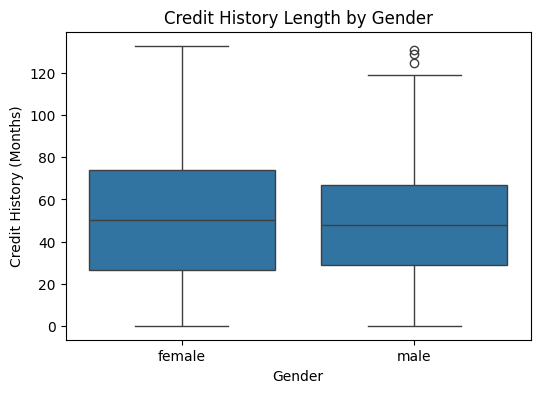

In [211]:
gender_df = df[df["applicant_info.gender"] != "unknown"]

plt.figure(figsize=(6,4))

sns.boxplot(
    data=gender_df,
    x="applicant_info.gender",
    y="financials.credit_history_months"
)

plt.title("Credit History Length by Gender")
plt.xlabel("Gender")
plt.ylabel("Credit History (Months)")
plt.show()

In [212]:
df.groupby("applicant_info.gender")["financials.annual_income"].mean()

applicant_info.gender
female     83770.648562
male       81295.546559
unknown    86500.000000
Name: financials.annual_income, dtype: float64

In [213]:
male = df[df["applicant_info.gender"]=="male"]["financials.annual_income"].dropna()
female = df[df["applicant_info.gender"]=="female"]["financials.annual_income"].dropna()

ttest_ind(male, female)

TtestResult(statistic=np.float64(-0.9823353175253775), pvalue=np.float64(0.32641359433857753), df=np.float64(496.0))

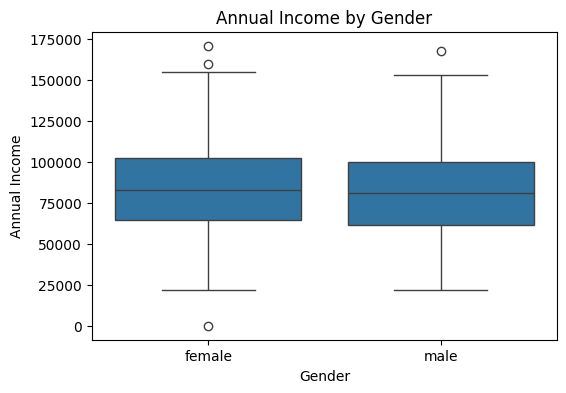

In [214]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=gender_df,
    x="applicant_info.gender",
    y="financials.annual_income"
)

plt.title("Annual Income by Gender")
plt.xlabel("Gender")
plt.ylabel("Annual Income")
plt.show()

To assess potential gender-based proxy effects, we examined whether the key decision variables identified in the regression—credit history length and annual income—differ significantly across genders. Independent t-tests show no statistically significant differences between male and female applicants for either credit history length (p = 0.555) or annual income (p = 0.326). This indicates that the financial variables influencing loan approval are similarly distributed across genders and therefore do not appear to function as indirect proxies for gender in the decision process.

#### **1.3.3. ZIP Code as potential Proxy**

In [215]:
df["zip_prefix"] = df["applicant_info.zip_code"].astype(str).str[:3]
zip_prefix_counts = df["zip_prefix"].value_counts().sort_index()
zip_prefix_counts

zip_prefix
100    251
300     18
902    230
nan      1
Name: count, dtype: int64

In [216]:
zip_df = df[df["zip_prefix"].notna()]
zip_df = zip_df[zip_df["zip_prefix"] != "nan"]

In [217]:
zip_prefix_summary = (
    zip_df.groupby("zip_prefix")
    .agg(
        approval_rate=("decision.loan_approved","mean"),
        n=("decision.loan_approved","count")
    )
)

zip_prefix_summary = zip_prefix_summary[zip_prefix_summary["n"] >= 10]
zip_prefix_summary

,approval_rate,n
zip_prefix,,
100,0.645418,251
300,0.555556,18
902,0.517391,230


In [218]:
ct_zip_approval = pd.crosstab(
    zip_df["zip_prefix"],
    zip_df["decision.loan_approved"]
)

print(ct_zip_approval)

decision.loan_approved  False  True 
zip_prefix                          
100                        89    162
300                         8     10
902                       111    119


In [219]:
chi2_zip, p_zip, dof_zip, expected_zip = chi2_contingency(ct_zip_approval)

print("Chi-square (ZIP vs Approval):", chi2_zip)
print("p-value:", p_zip)

Chi-square (ZIP vs Approval): 8.151470683069979
p-value: 0.016979724188695876


In [220]:
n = ct_zip_approval.sum().sum()
r, k = ct_zip_approval.shape

cramers_v_zip = np.sqrt(chi2_zip / (n * (min(r-1, k-1))))

print("Cramér's V (ZIP → Approval):", cramers_v_zip)

Cramér's V (ZIP → Approval): 0.12781084692357925


To assess whether geographic information could influence lending decisions, we analyzed the relationship between ZIP code prefixes and loan approval outcomes. A Chi-square test of independence indicated a statistically significant association between ZIP prefix and approval decisions (χ² = 8.15, p = 0.017). However, the effect size measured using Cramér’s V was relatively small (V = 0.13), indicating a weak association. While geographic location appears to have a statistically detectable relationship with approval outcomes, the magnitude of this effect is limited. Since an association between ZIP prefix and approval decisions exist, it will be further investigated if the ZIP prefix could be a Proxy to socioeconomic and demographic fatcors such as income, gender and age.

In [221]:
zip_df.groupby("zip_prefix")["financials.annual_income"].mean()

zip_prefix
100    81055.776892
300    84000.000000
902    84180.142561
Name: financials.annual_income, dtype: float64

<Axes: xlabel='zip_prefix', ylabel='financials.annual_income'>

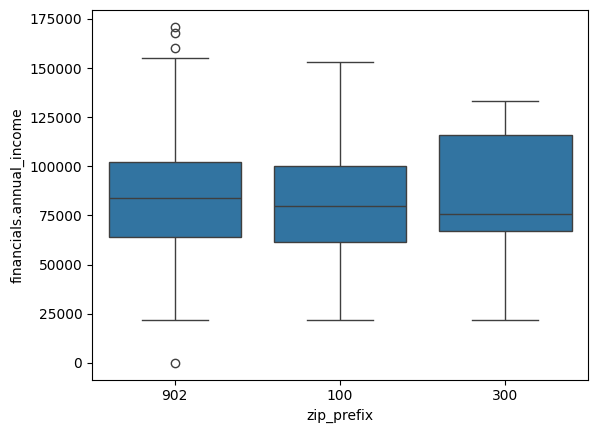

In [222]:
sns.boxplot(
    data=zip_df,
    x="zip_prefix",
    y="financials.annual_income"
)

In [223]:
groups_income = [
    group["financials.annual_income"].dropna().values
    for name, group in zip_df.groupby("zip_prefix")
]

f_stat_inc, p_val_inc = stats.f_oneway(*groups_income)

print("ANOVA F-statistic (ZIP vs Income):", f_stat_inc)
print("p-value:", p_val_inc)

NameError: name 'stats' is not defined

In [ ]:
def correlation_ratio(categories, values):
    
    df_temp = pd.DataFrame({"cat": categories, "val": values}).dropna()

    group_means = df_temp.groupby("cat")["val"].mean()
    group_counts = df_temp.groupby("cat")["val"].count()

    grand_mean = df_temp["val"].mean()

    ss_between = ((group_means - grand_mean) ** 2 * group_counts).sum()
    ss_total = ((df_temp["val"] - grand_mean) ** 2).sum()

    return np.sqrt(ss_between / ss_total)

eta_income = correlation_ratio(zip_df["zip_prefix"], zip_df["financials.annual_income"])

print("Correlation ratio η (ZIP → Income):", eta_income)

Correlation ratio η (ZIP → Income): 0.05539942833202696


To investigate whether ZIP codes capture socioeconomic differences, we analyzed the relationship between ZIP prefixes and annual income using ANOVA and the correlation ratio (η). The ANOVA test showed no statistically significant differences in income across ZIP regions (F = 0.76, p = 0.467). The correlation ratio was also very low (η = 0.055), indicating that ZIP code explains only a negligible portion of income variation. These findings suggest that geographic location does not meaningfully reflect income differences in the dataset and therefore does not act as a proxy for income.

In [ ]:
# keep only valid rows for gender-ratio analysis
zip_df_ratio = zip_df[
    (zip_df["zip_prefix"].notna()) &
    (zip_df["zip_prefix"] != "nan") &
    (zip_df["applicant_info.gender"].notna()) &
    (~zip_df["applicant_info.gender"].str.lower().eq("unknown"))
].copy()

# crosstab + row-wise gender ratios
ct = pd.crosstab(
    zip_df_ratio["zip_prefix"],
    zip_df_ratio["applicant_info.gender"]
)

gender_ratio = ct.div(ct.sum(axis=1), axis=0)

print(gender_ratio)

applicant_info.gender    female      male
zip_prefix                               
100                    0.112000  0.888000
300                    0.444444  0.555556
902                    0.934783  0.065217


In [ ]:
ct = pd.crosstab(zip_df["zip_prefix"], zip_df["applicant_info.gender"])

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("p-value:", p)

n = ct.sum().sum()
r, k = ct.shape

cramers_v = np.sqrt(chi2 / (n * (min(r-1, k-1))))

print("Cramer's V:", cramers_v)

Chi-square: 325.6965325958849
p-value: 3.092704382097556e-69
Cramer's V: 0.5712698408440628


To investigate whether geographic information could act as a proxy for protected attributes, we analyzed the relationship between ZIP code prefixes and gender. A Chi-square test of independence revealed a statistically significant association between ZIP prefix and gender (χ² = 325.69, p < 0.001).

To assess the strength of this relationship, we calculated Cramér’s V, which resulted in a value of 0.57. This indicates a  strong association between geographic location and gender distribution in the dataset.

These results suggest that ZIP codes contain substantial demographic information and could potentially act as a proxy variable for gender if used in predictive models.

In [ ]:
groups = [group["age"].dropna().values for name, group in zip_df.groupby("zip_prefix")]

f_stat, p_val = stats.f_oneway(*groups)

print("ANOVA F-statistic (ZIP vs Age):", f_stat)
print("p-value:", p_val)

ANOVA F-statistic (ZIP vs Age): 0.41224028890475944
p-value: 0.662393186070129


In [ ]:
eta_age = correlation_ratio(zip_df["zip_prefix"], zip_df["age"])

print("Correlation ratio η (ZIP → Age):", eta_age)

Correlation ratio η (ZIP → Age): 0.040860521663374644


To examine whether geographic location could act as a proxy for age, we analyzed the relationship between ZIP code prefixes and applicant age using ANOVA and the correlation ratio (η). The ANOVA test showed no statistically significant differences in age across ZIP regions (F = 0.41, p = 0.662). Additionally, the correlation ratio was very low (η = 0.04), indicating a negligible association between ZIP code and age. These results suggest that ZIP code does not meaningfully capture age-related information and therefore does not act as a proxy for age in this dataset.

In [ ]:
eta_income = correlation_ratio(zip_df["zip_prefix"], zip_df["financials.annual_income"])

print("Correlation ratio η (ZIP → Income):", eta_income)

Correlation ratio η (ZIP → Income): 0.05539942833202696


#### **1.3.4. Proxy Summary**

The proxy analysis examined whether financial variables capture information related to age or gender that could indirectly influence lending decisions. First, we identified the financial variables with a significant impact on loan approval using a logistic regression model, namely credit_history_months and applicant.annual_income. We then tested whether these variables may act as proxies for protected attributes. The results suggest that credit_history_months could potentially act as a proxy for age, as it contains age-related information while also significantly influencing lending outcomes. In contrast, the analysis indicates that neither credit_history_months nor applicant.annual_income capture meaningful information related to gender.

In addition to financial variables, ZIP code prefixes were evaluated as potential proxy variables capturing demographic or socioeconomic information. The results reveal a strong association between ZIP code and gender (high Cramér’s V), suggesting that geographic location contains substantial gender-related information. However, no meaningful relationships were found between ZIP code and age or income, as ANOVA tests were not statistically significant and the correlation ratios (η) were negligible. Although ZIP code showed a statistically significant relationship with loan approval outcomes, the effect size was weak, indicating only a limited influence of geographic location on lending decisions. Overall, while ZIP code may contain gender-related demographic signals, its practical impact on approval outcomes appears limited in this dataset.

## **2.Fairness Metrics**

Building on the bias analysis, this section evaluates fairness in the lending decisions using quantitative fairness metrics. We apply metrics such as Demographic Parity and the Disparate Impact Ratio to assess whether loan approval rates differ systematically across demographic groups, particularly gender and age. These metrics provide a structured way to measure potential disparities in outcomes and help determine whether the decision process may lead to unequal treatment across groups.

### **2.1. Demographic Parity**

In [ ]:
# selection rates
mf_gender = MetricFrame(
    metrics=selection_rate,
    y_true=gender_df["decision.loan_approved"],
    y_pred=gender_df["decision.loan_approved"],
    sensitive_features=gender_df["applicant_info.gender"]
)

gender_rates = mf_gender.by_group.round(2)

# demographic parity difference
dp_gender = demographic_parity_difference(
    y_true=gender_df["decision.loan_approved"],
    y_pred=gender_df["decision.loan_approved"],
    sensitive_features=gender_df["applicant_info.gender"]
)

# combine output
gender_summary = pd.concat([
    gender_rates,
    pd.Series({"Demographic_Parity": round(dp_gender, 2)})
])

gender_summary

female                0.51
male                  0.66
Demographic_Parity    0.15
dtype: float64

In [ ]:
# remove NaN age groups
age_df = df.dropna(subset=["age_group"])

# selection rates
mf_age = MetricFrame(
    metrics=selection_rate,
    y_true=age_df["decision.loan_approved"],
    y_pred=age_df["decision.loan_approved"],
    sensitive_features=age_df["age_group"]
)

age_rates = mf_age.by_group.round(2)

# demographic parity difference
dp_age = demographic_parity_difference(
    y_true=age_df["decision.loan_approved"],
    y_pred=age_df["decision.loan_approved"],
    sensitive_features=age_df["age_group"]
)

# combine output
age_summary = pd.concat([
    age_rates,
    pd.Series({"Demographic_Parity (Maximal difference)": round(dp_age, 2)})
])

age_summary

18-24                                      0.50
25-34                                      0.45
35-44                                      0.66
45-54                                      0.64
55-64                                      0.62
65+                                        0.54
Demographic_Parity (Maximal difference)    0.22
dtype: float64

The demographic parity analysis shows that the loan approval rate between genders results in a demographic parity difference of 15%, suggesting that loan approvals are not independent of gender. A similar pattern appears across age groups, where approval rates range from 45% (25–34) to 66% (35–44), producing a demographic parity difference of 0.22. This indicates an even larger disparity across age categories, with younger applicants receiving approvals less frequently than middle-aged applicants.

### **2.2. Disparate Impact Ratio**

#### **2.2.1. Disparate Gender Ratio**

In [ ]:
gender_df = df[df["applicant_info.gender"].notna()]
gender_df = gender_df[gender_df["applicant_info.gender"] != "unknown"]

In [ ]:
# approval rate by gender
approval_rates = gender_df.groupby("applicant_info.gender")["decision.loan_approved"].mean().round(2)

female_rate = approval_rates["female"].round(2)
male_rate = approval_rates["male"].round(2)

di_ratio = (female_rate / male_rate).round(2)

print("Female approval rate:", female_rate)
print("Male approval rate:", male_rate)
print("Disparate Impact Ratio:", di_ratio)

if di_ratio < 0.8:
    print("Potential disparate impact detected (violates 80% rule).")
else:
    print("No disparate impact detected.")

Female approval rate: 0.51
Male approval rate: 0.66
Disparate Impact Ratio: 0.77
Potential disparate impact detected (violates 80% rule).


C:\Users\Behnia\AppData\Local\Temp\ipykernel_23964\3940286355.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=plot_rates.index, y=plot_rates.values, palette=colors)


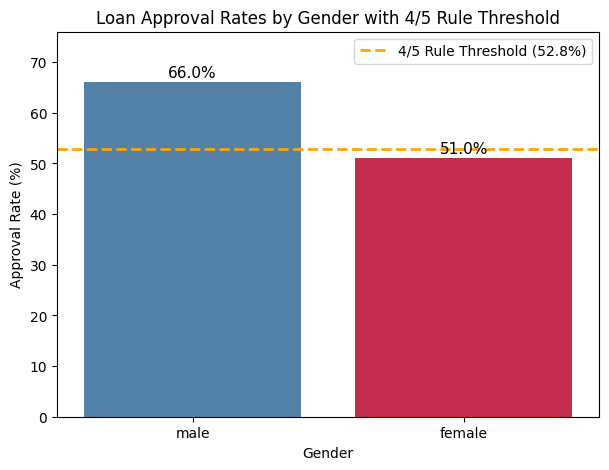

In [ ]:
# approval rates
approval_rates = gender_df.groupby("applicant_info.gender")["decision.loan_approved"].mean().round(2)

# keep only groups used for DI
plot_rates = approval_rates[["male", "female"]] * 100

male_rate = plot_rates["male"]
female_rate = plot_rates["female"]

# 4/5 rule threshold = 80% of reference group
threshold = 0.8 * male_rate

plt.figure(figsize=(7,5))

# define colors: male = blue, female = red
colors = ["steelblue", "crimson"]

ax = sns.barplot(x=plot_rates.index, y=plot_rates.values, palette=colors)

# labels on bars
for i, v in enumerate(plot_rates.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=11)

# threshold line
plt.axhline(threshold, linestyle="--", linewidth=2, color="orange",
            label=f"4/5 Rule Threshold ({threshold:.1f}%)")

plt.ylabel("Approval Rate (%)")
plt.xlabel("Gender")
plt.title("Loan Approval Rates by Gender with 4/5 Rule Threshold")
plt.ylim(0, max(plot_rates.max() + 10, threshold + 10))

plt.legend()
plt.show()

The approval rate for male applicants is 66.0%, while female applicants have an approval rate of 51.0%. According to the four-fifths rule, the minimum acceptable approval rate for female applicants would be 52.8% (80% of the male approval rate). Since the female approval rate falls below this threshold, the disparate impact ratio is 0.77, indicating potential adverse impact against female applicants.

#### **2.2.2. Disparate Age Ratio**

In [ ]:
age_rates = df.groupby("age_group")["decision.loan_approved"].mean()

age_rates.round(2)

C:\Users\Behnia\AppData\Local\Temp\ipykernel_23964\2268722606.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rates = df.groupby("age_group")["decision.loan_approved"].mean()


age_group
18-24    0.50
25-34    0.45
35-44    0.66
45-54    0.64
55-64    0.62
65+      0.54
Name: decision.loan_approved, dtype: float64

In [ ]:
age_bias_df = pd.DataFrame({
    "approval_rate": age_rates.round(2),
    "DI_ratio": (age_rates / reference_rate).round(2)
})

age_bias_df["below_80pct_rule"] = age_bias_df["DI_ratio"] < 0.8

age_bias_df

,approval_rate,DI_ratio,below_80pct_rule
age_group,,,
18-24,0.50,0.76,True
25-34,0.45,0.68,True
35-44,0.66,1.00,False
45-54,0.64,0.97,False
55-64,0.62,0.95,False
65+,0.54,0.82,False


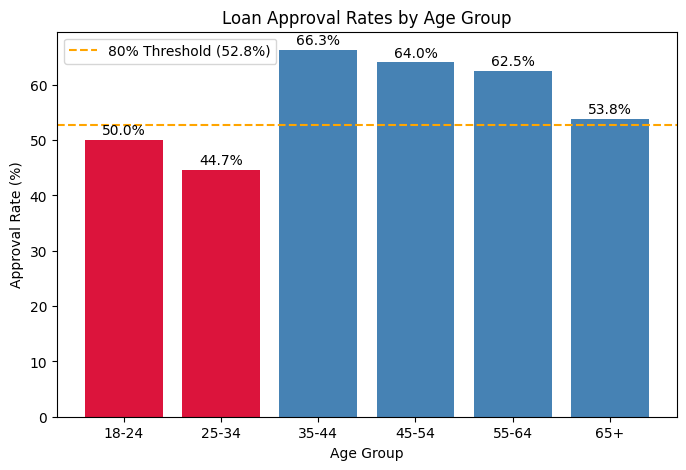

In [ ]:
threshold = 0.8 * reference_rate * 100
plot_rates = age_rates * 100

# color bars based on threshold
colors = ["crimson" if rate < threshold else "steelblue" for rate in plot_rates]

plt.figure(figsize=(8,5))
ax = plt.bar(plot_rates.index, plot_rates.values, color=colors)

# labels on bars
for i, v in enumerate(plot_rates.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

# threshold line
plt.axhline(threshold, linestyle="--", color="orange",
            label=f"80% Threshold ({threshold:.1f}%)")

plt.ylabel("Approval Rate (%)")
plt.xlabel("Age Group")
plt.title("Loan Approval Rates by Age Group")
plt.legend()

plt.show()

Approval rates vary across age groups, with the 35–44 group showing the highest approval rate (66%), which serves as the reference group. Applying the 80% rule, the minimum acceptable approval rate for other age groups is 52.8%. The 18–24 (50%) and 25–34 (45%) groups fall below this threshold, suggesting potential adverse impact against younger applicants, while all other age groups remain above the threshold.

### **2.3. Limitations and Governance Recommendation**

A limitation of this analysis is that fairness metrics such as Equalized Odds cannot be evaluated because the dataset does not contain ground-truth outcomes (e.g., loan repayment or default). Without these labels, it is not possible to compare error rates across groups, and the analysis is therefore limited to selection-based fairness metrics such as Disparate Impact and Demographic Parity. 

Additionally, fairness metrics often involve trade-offs: enforcing equal approval rates across groups could conflict with legitimate risk signals, such as differences in credit history or financial stability that may correlate with age.

The results show disparities in approval rates both across gender (DI = 0.77; DP difference = 0.15) and age groups (DP difference = 0.22), with particularly lower approval rates for younger applicants. This highlights the common fairness trade-off, where enforcing equal approval rates across groups may conflict with risk-related factors such as shorter credit histories among younger applicants. As a governance measure, NovaCred should implement regular fairness monitoring of approval rates by gender and age, and conduct targeted audits of variables such as credit_history_months, which may act as proxies for age and indirectly influence lending decisions.